In [ ]:
import numpy as np
import cv2
from pyproj import Transformer
from my_vbr_utils.vbr_dataset import vbrInterpolatedDataset, load_calibration, get_paths_from_scene
from my_vbr_utils.utilities import load_scene_correspondences
from my_utils.plotting import show_image_pair
# --- Config and Dataset Loading ---
# Set these variables to configure your scene and utility path
scene_name = 'spagna_train0'
dataset_root_dir = "/datasets/vbr_slam"
calib_path = get_paths_from_scene(dataset_root_dir, scene_name)[-1]
calib = load_calibration(calib_path)

dataset = vbrInterpolatedDataset(dataset_root_dir,scene_name)
# print(model)

Loaded vbrInterpolatedDataset from scene:  spagna_train0
Images loaded from:  /datasets/vbr_slam/spagna/spagna_train0_kitti/camera_left/data
Ground Truth Poses:  /datasets/vbr_slam/spagna/spagna_train0/spagna_train0_gt.txt


In [2]:
# import ipywidgets as widgets
# from ipywidgets import interact, interactive, fixed, interact_manual
# from IPython.display import display
# import matplotlib.pyplot as plt
# import pandas as pd
# from PIL import Image
# # Assuming you have this function defined elsewhere in your notebook or in a module
# from my_utils.plotting import show_image_pair  # Replace with your actual import

# # Load the CSV file
# pairs_df = pd.read_csv('/home/bjangley/VPR/mast3r-v2/pairs_mining/ciampino_train0/ciampino_matches_inliers_fm_top5_anchors_per_query.csv')

# # Define the inlier ranges you're interested in
# inlier_ranges = [(i, i + 200) for i in range(200, 1800, 200)]


# # Create a dictionary to store the selected queries and their anchors
# selected_queries = {}

# # Iterate through the inlier ranges
# for i, (min_inliers, max_inliers) in enumerate(inlier_ranges):
#     # Filter the DataFrame for the current inlier range
#     filtered_df = pairs_df[(pairs_df['num_inliers'] >= min_inliers) & (pairs_df['num_inliers'] < max_inliers)]
    
#     # If there are any pairs in the current range, select the first query and all its anchors
#     if not filtered_df.empty:
#         # Get the first query_idx in the filtered DataFrame
#         query_idx = filtered_df['query_idx'].iloc[0]
        
#         # Get all rows (anchor-query pairs) associated with this query_idx
#         query_pairs_df = pairs_df[pairs_df['query_idx'] == query_idx]
        
#         # Store the query_idx and its associated anchor pairs in the dictionary
#         selected_queries[f'range_{i}'] = {
#             'query_idx': query_idx,
#             'anchor_pairs': query_pairs_df
#         }
#         # print(f"Found query {query_idx} with pairs in range {min_inliers}-{max_inliers-1} inliers")
#     else:
#         print(f"No queries found in range {min_inliers}-{max_inliers-1} inliers")

# # # Print the selected queries and their anchor pairs
# # print("\nSelected Queries and Anchor Pairs:")
# # for key, value in selected_queries.items():
# #     print(f"\n{key}:")
# #     print(f"  Query Index: {value['query_idx']}")
# #     print("  Anchor Pairs:")
# #     print(value['anchor_pairs'])
# # Function to display query and anchor images for a given range
# def display_images_for_range(range_index):
#     if 0 <= range_index < len(inlier_ranges):
#         min_inliers, max_inliers = inlier_ranges[range_index]
#         filtered_df = pairs_df[(pairs_df['num_inliers'] >= min_inliers) & (pairs_df['num_inliers'] < max_inliers)]

#         if not filtered_df.empty:
#             # Select up to 3 queries from the filtered DataFrame
#             num_queries_to_display = min(3, filtered_df['query_idx'].nunique())
#             query_idxs = filtered_df['query_idx'].unique()[:num_queries_to_display]

#             # Create a single figure with enough subplots
#             fig, axes = plt.subplots(len(query_idxs), 2, figsize=(10, 5*len(query_idxs)))  # 2 columns: Query and Anchor
#             if len(query_idxs) == 1:
#                 axes = [axes]

#             fig.suptitle(f"Inlier Range: {min_inliers}-{max_inliers-1}")

#             for i, query_idx in enumerate(query_idxs):
#                 # Get the first anchor-query pair for this query_idx within the inlier range
#                 query_pairs_df = filtered_df[filtered_df['query_idx'] == query_idx].iloc[[0]]

#                 # Load and display the anchor image
#                 index, row = query_pairs_df.iterrows().__next__()  # Get the first row
#                 anchor_idx = int(row['anchor_idx'])
#                 anchor = dataset[anchor_idx]
#                 anchor_img = Image.open(anchor['image'])
#                 axes[i,0].imshow(anchor_img)
#                 axes[i,0].set_title(f"Anchor {anchor_idx}")
#                 axes[i,0].axis('off')  # Hide axes

#                 # Load and display the query image
#                 query = dataset[int(query_idx)]
#                 query_img = Image.open(query['image'])

#                 num_matches = row['num_matches']
#                 num_inliers = row['num_inliers']
#                 axes[i,1].imshow(query_img)
#                 axes[i,1].set_title(f"Query {query_idx}\nMatches: {num_matches}, Inliers: {num_inliers}")
#                 axes[i,1].axis('off')

#             plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make room for the suptitle
#             plt.show()
#         else:
#             print(f"No queries found in range {min_inliers}-{max_inliers-1} inliers")
#     else:
#         print("Invalid range index")

# # Create an interactive slider
# range_slider = widgets.IntSlider(
#     min=0,
#     max=len(inlier_ranges) - 1,
#     step=1,
#     value=0,
#     description='Inlier Range:'
# )

# # Use interact to connect the slider to the display function
# interact(display_images_for_range, range_index=range_slider)

In [3]:
### LOAD MAST3R MODEL AND INFERENCE UTILITIES
from mast3r.model import AsymmetricMASt3R
#load model
device = 'cuda:6'


CHECKPOINT = "naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric"
# CHECKPOINT="/home/bjangley/VPR/mast3r-v2/checkpoints_v1/campus_ciampino2_lr5e5_3e6_reg/checkpoint-4.pth"
# CHECKPOINT="/home/bjangley/VPR/mast3r-v2/checkpoints_v1/ciampino1_ciampino2_lr5e5_3e6/checkpoint-2.pth"
model = AsymmetricMASt3R.from_pretrained(CHECKPOINT).to(device)

/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/model.py:205: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/bjangley/VPR/mast3r-v2/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0039215684..255.0].


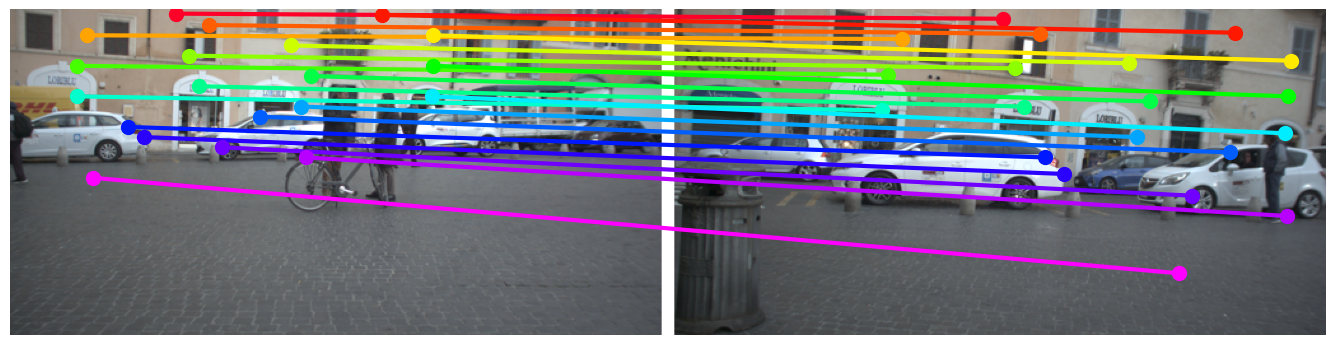

Fundamental matrix: 657 matches, 639 inliers, 18 outliers
Mast3r image shape:  256 512


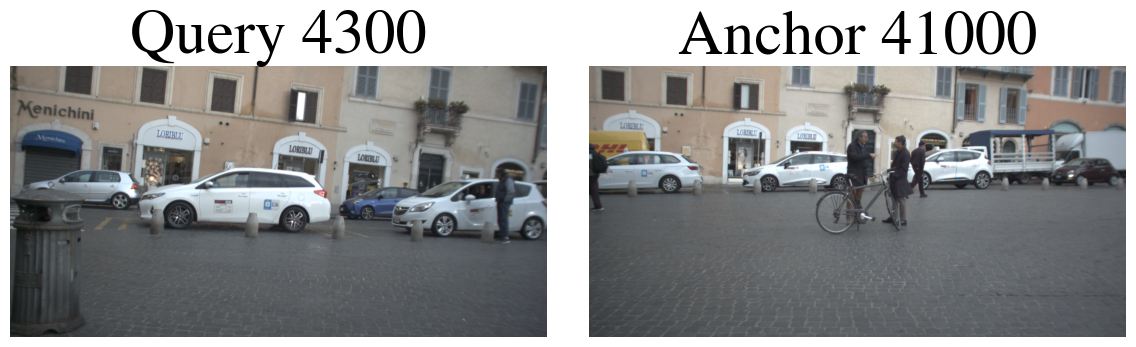

In [27]:
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as Rscipy
from my_utils.mast3r_utils import get_master_output, get_mast3r_image_shape,scale_intrinsics,overlap,plot_depth_overlay_on_image,plot_lidar_mast3r_matches
from my_utils.my_vbr_dataset import generate_depth_and_scene_maps
from my_utils.mast3r_utils import recompute_intrinsics
# --- Load anchor-query pair ---
pairs_df = pd.read_csv('/home/bjangley/VPR/mast3r-v2/pairs_mining/spagna_train0/spagna_matches_inliers_fm_top10_anchors_per_query.csv')
# row = pairs_df.iloc[10]
# row = pairs_df.iloc[800]
# row = pairs_df.iloc[130]
row = pairs_df.iloc[440]

anchor_idx, query_idx = int(row['anchor_idx']), int(row['query_idx'])
# anchor_idx = 38750
anchor = dataset[anchor_idx]
query  = dataset[query_idx]
gt_pose = query['pose']

# --- Run MASt3R model and extract matches ---
output = get_master_output(
    model, device,
    anchor['image'],
    query['image'],
    visualize=True,
    verbose=False
)
matches_im0 = output[0]
matches_im1 = output[1]
pts3d_im0   = output[2]


# --- find number of inliers from the matches ---
if len(matches_im0) >= 8:
    F, mask_f = cv2.findFundamentalMat(matches_im0, matches_im1, cv2.FM_RANSAC, 1, 0.99)
    num_inliers_f = int(mask_f.sum()) if mask_f is not None else 0
    inlier_mask = mask_f.ravel().astype(bool)
    inlier_im0 = matches_im0[inlier_mask]
    inlier_im1 = matches_im1[inlier_mask]
else:
    num_inliers_f = 0
    inlier_im0 = np.empty((0, 2))
    inlier_im1 = np.empty((0, 2))
print(f"Fundamental matrix: {len(matches_im0)} matches, {num_inliers_f} inliers, {len(matches_im0) - num_inliers_f} outliers")

T_cam_lidar = calib['cam_l']['T_cam_lidar']
K = calib['cam_l']['K']
# --- LiDAR projection and image resizing ---
img = cv2.imread(anchor['image'])
H, W = img.shape[:2]
mast3r_w, mast3r_h = get_mast3r_image_shape(W, H)
print("Mast3r image shape: ", mast3r_h, mast3r_w)
# K_new = scale_intrinsics(K, W, H, mast3r_w, mast3r_h)
K_new = recompute_intrinsics(K,(W,H),size=512)
depth_map, scene_map = generate_depth_and_scene_maps(anchor['lidar_points'], K_new, T_cam_lidar, (mast3r_h, mast3r_w))

# --- Load and show anchor/query images ---
anchor_img = Image.open(anchor['image'])
query_img = Image.open(query['image'])
show_image_pair(anchor_img, query_img, anchor_idx, query_idx)

# --- LiDAR depth overlay ---
img_orig = plt.imread(anchor['image'])
img_resized = cv2.resize(img_orig, (mast3r_w, mast3r_h))
img_resized = img_resized.astype(np.float32) / 255.0 if img_resized.dtype == np.uint8 else img_resized
v, u = np.where(np.isfinite(depth_map))
pixel_uv = np.stack((u, v), axis=-1)



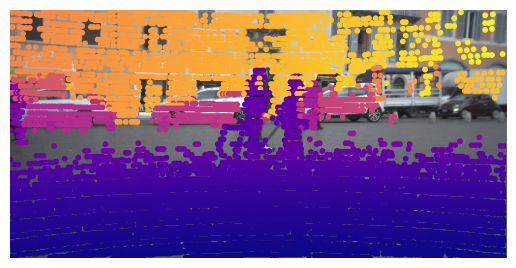

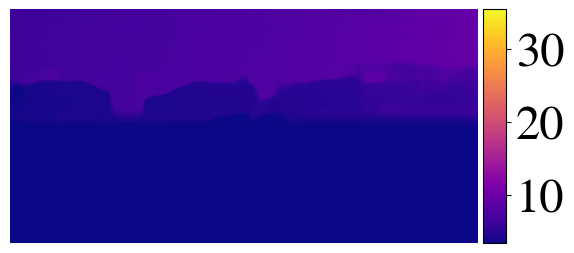

In [28]:
from my_utils.mast3r_utils import plot_depth_overlay_on_image
from mpl_toolkits.axes_grid1 import make_axes_locatable
v, u = np.where(np.isfinite(depth_map))
pixel_uv = np.stack((u, v), axis=-1)
plot_depth_overlay_on_image(img_resized, scene_map, pixel_uv, point_size=10, alpha=1.0, title="")


pts3d=output[2]
vmax = np.nanmax(scene_map[:,:,2])  # Use the maximum value from scene_map for scaling
vmin = np.nanmin(scene_map[:,:,2])  # Use the minimum value from scene_map for scaling

fig, ax = plt.subplots()
im = ax.imshow(pts3d[:,:,2], cmap='plasma', vmax=vmax, vmin=vmin)
# ax.set_title("MASt3R Depth Map (with scaling)")
# Create a divider for the axes
divider = make_axes_locatable(ax)
# Add an axes to the right of the image whose width is 5% of the original axes.
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(im, cax=cax)  # Use fig.colorbar and pass the image
ax.axis('off')
plt.show()

depthanything_depthmaps = f"/home/bjangley/VPR/depthanything_80/{scene_name}/{str(anchor_idx).zfill(10)}.npy"
depthpro_depthmaps=f"/home/bjangley/VPR/depthpro_vbr/{scene_name}/{str(anchor_idx).zfill(10)}.npy"
zoedepth_depthmaps=f"/home/bjangley/VPR/zoedepth_vbr/{scene_name}/{str(anchor_idx).zfill(10)}.npy"

# import matplotlib.pyplot as plt
# import numpy as np

# # Load the depth maps
# depthanything = np.load(depthanything_depthmaps)
# depthpro = np.load(depthpro_depthmaps)
# zoedepth = np.load(zoedepth_depthmaps)

# # Create a figure with subplots
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# # Display DepthAnything depth map
# im1 = axes[0].imshow(depthanything, cmap='viridis')
# axes[0].set_title('DepthAnything')
# axes[0].axis('off')
# fig.colorbar(im1, ax=axes[0], shrink=0.75)

# # Display DepthPro depth map
# im2 = axes[1].imshow(depthpro, cmap='viridis')
# axes[1].set_title('DepthPro')
# axes[1].axis('off')
# fig.colorbar(im2, ax=axes[1], shrink=0.75)

# # Display ZoeDepth depth map
# im3 = axes[2].imshow(zoedepth, cmap='viridis')
# axes[2].set_title('ZoeDepth')
# axes[2].axis('off')
# fig.colorbar(im3, ax=axes[2], shrink=0.75)

# # Adjust layout and display the

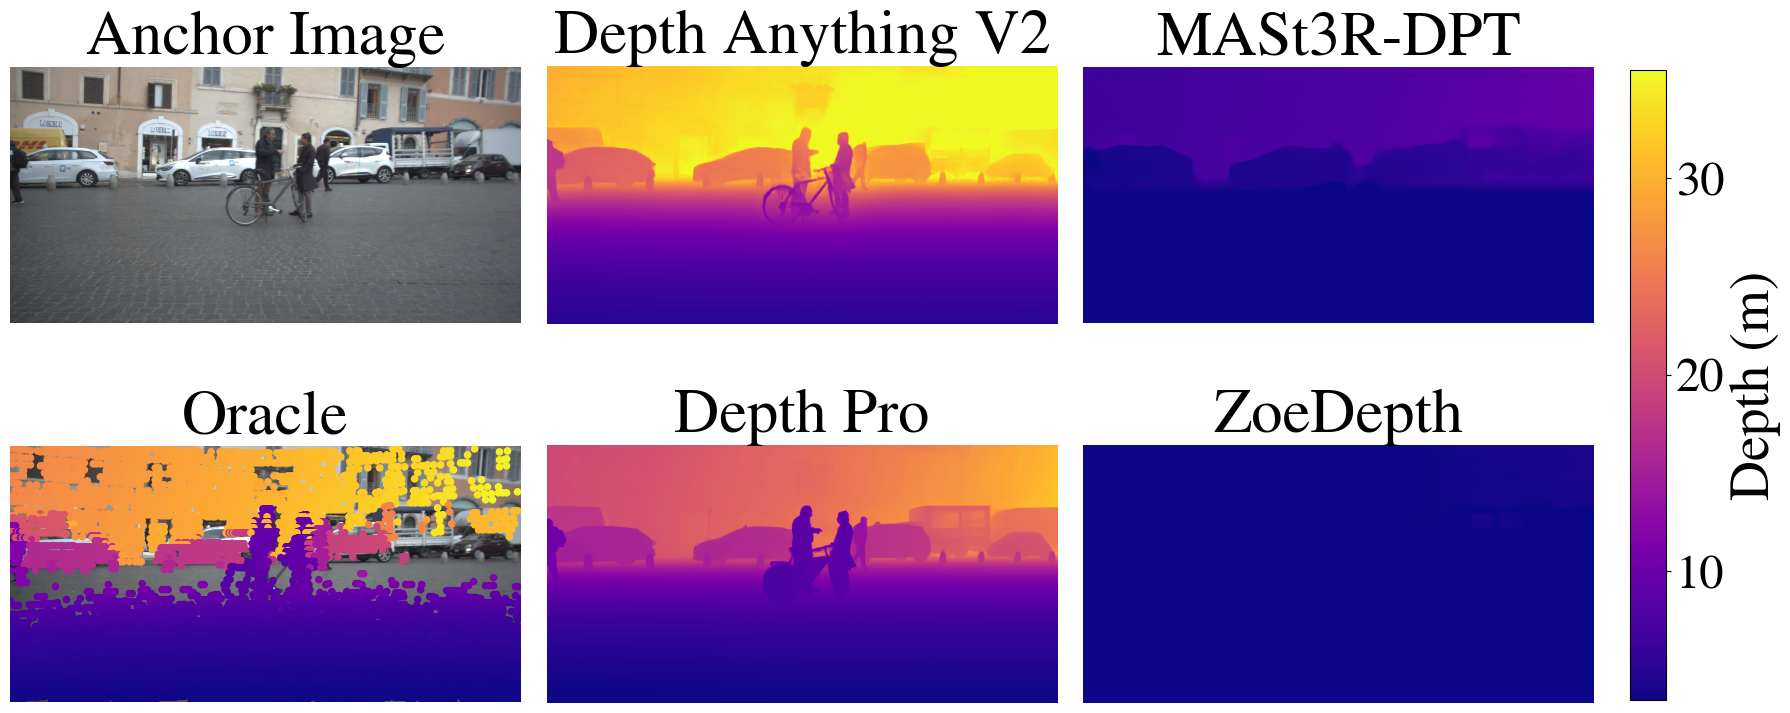

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 28,
    "axes.titlesize": 45,
    "axes.labelsize": 40,
    "xtick.labelsize": 18,
    "ytick.labelsize": 35,
    "legend.fontsize": 40,
    "font.family": "STIXGeneral",
})

def plot_depth_overlay_on_axes(ax, img, scene_map, pixel_uv, cmap='plasma', alpha=1.0, point_size=40, vmin=None, vmax=None):
    """Overlay depth values from scene_map onto given matplotlib Axes."""
    u = pixel_uv[:, 0]
    v = pixel_uv[:, 1]
    depth = scene_map[v, u][:, 2]
    im = ax.imshow(img, origin='upper')
    scatter = ax.scatter(u, v, c=depth, cmap=cmap, s=point_size,
                         alpha=alpha, vmin=vmin, vmax=vmax)
    return scatter

# --- Anchor image ---
anchor_img = cv2.imread(anchor['image'])
anchor_img = cv2.cvtColor(anchor_img, cv2.COLOR_BGR2RGB)

# --- Valid LiDAR points ---
v, u = np.where(np.isfinite(depth_map))
pixel_uv = np.stack((u, v), axis=-1)

# Depth maps
mast3r_depth = pts3d[:, :, 2]
depthanything = np.load(depthanything_depthmaps)
depthpro = np.load(depthpro_depthmaps)
zoedepth = np.load(zoedepth_depthmaps)

# Scaling from LiDAR
vmin = np.nanmin(scene_map[v, u][:, 2])
vmax = np.nanmax(scene_map[v, u][:, 2])

# --- Setup grid ---
fig, axes = plt.subplots(2, 3, figsize=(18, 9))  # slightly shorter figure
fig.subplots_adjust(left=0.02, right=0.9, top=0.92, bottom=0.08,
                    wspace=0.05, hspace=0.005)  # reduce hspace

# 1. Anchor image
axes[0, 0].imshow(img_resized)
axes[0, 0].set_title("Anchor Image")
axes[0, 0].axis("off")

# 2. DepthAnything
im_da = axes[0, 1].imshow(depthanything, cmap='plasma', vmin=vmin, vmax=vmax)
axes[0, 1].set_title("Depth Anything V2")
axes[0, 1].axis("off")

# 3. MASt3R
im_ma = axes[0, 2].imshow(mast3r_depth, cmap='plasma', vmin=vmin, vmax=vmax)
axes[0, 2].set_title("MASt3R-DPT")
axes[0, 2].axis("off")

# 4. Oracle (LiDAR overlay)
scatter = plot_depth_overlay_on_axes(
    axes[1, 0], img_resized, scene_map, pixel_uv,
    cmap='plasma', point_size=20, alpha=1.0,
    vmin=vmin, vmax=vmax
)
axes[1, 0].set_title("Oracle")
axes[1, 0].axis("off")

# 5. DepthPro
im_dp = axes[1, 1].imshow(depthpro, cmap='plasma', vmin=vmin, vmax=vmax)
axes[1, 1].set_title("Depth Pro")
axes[1, 1].axis("off")

# 6. ZoeDepth
im_zoe = axes[1, 2].imshow(zoedepth, cmap='plasma', vmin=vmin, vmax=vmax)
axes[1, 2].set_title("ZoeDepth")
axes[1, 2].axis("off")

# --- Shared colorbar on the right ---
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im_dp, cax=cbar_ax)
cbar.set_label("Depth (m)")

plt.show()


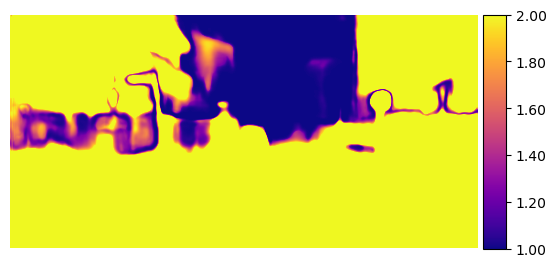

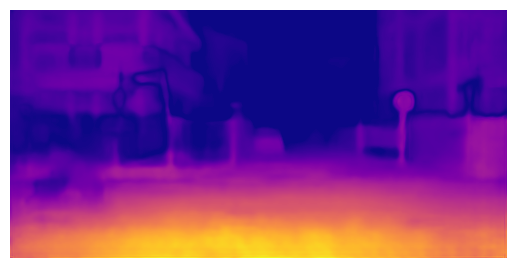

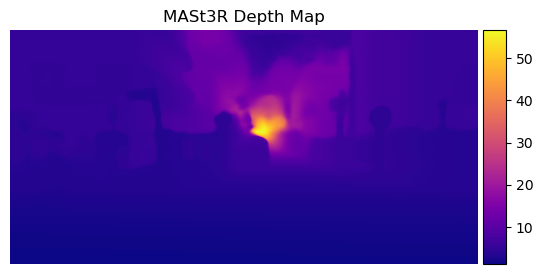

In [19]:

# print(f"Min depth: {depth_min}, Max depth: {depth_max}")
conf_im0 = output[4]

fig, ax = plt.subplots()
im = ax.imshow(conf_im0, cmap='plasma', vmin=1, vmax=2)
# ax.set_title("Predicted Confidence Map")

# Create a divider for the axes
divider = make_axes_locatable(ax)

# Add an axes to the right of the image whose width is 5% of the original axes.
cax = divider.append_axes("right", size="5%", pad=0.05)

# Add colorbar to the specified axes
cbar = fig.colorbar(im, cax=cax, format='%.2f')

ax.axis('off')
plt.show()

# # Remove outliers using percentile clipping
# lower, upper = np.percentile(conf_im0[np.isfinite(conf_im0)], [0, 100])
# conf_im0_clipped = np.clip(conf_im0, lower, upper)

# # Normalize to [0, 1]
# conf_im0_norm = (conf_im0_clipped - lower) / (upper - lower)

# fig, ax = plt.subplots()
# im = ax.imshow(conf_im0_norm, cmap='plasma')
# ax.set_title("Normalized Confidence Map (Outliers Removed)")

# # Create a divider for the axes
# divider = make_axes_locatable(ax)

# # Add an axes to the right of the image whose width is 5% of the original axes.
# cax = divider.append_axes("right", size="5%", pad=0.05)

# # Add colorbar to the specified axes
# cbar = fig.colorbar(im, cax=cax, format='%.2f')

# ax.axis('off')
# plt.show()


# Remove outliers using percentile clipping
lower, upper = np.percentile(conf_im0[np.isfinite(conf_im0)], [0, 100])

# Normalize the original confidence map using the clipped range
conf_im0_norm = (conf_im0 - lower) / (upper - lower)

# Clip the normalized values to be within [0, 1]
conf_im0_norm = np.clip(conf_im0_norm, 0, 1)

fig, ax = plt.subplots()
im = ax.imshow(conf_im0_norm, cmap='plasma')
# ax.set_title("Normalized Confidence Map (Outliers Scaled)")

# Create a divider for the axes
divider = make_axes_locatable(ax)

# # Add an axes to the right of the image whose width is 5% of the original axes.
# cax = divider.append_axes("right", size="5%", pad=0.05)

# # Add colorbar to the specified axes
# cbar = fig.colorbar(im, cax=cax, format='%.2f')

ax.axis('off')
plt.show()


pts3d=output[2]
fig, ax = plt.subplots()
im = ax.imshow(pts3d[:,:,2], cmap='plasma') #, vmin = depth_min, vmax=depth_max
ax.set_title("MASt3R Depth Map")

# Create a divider for the axes
divider = make_axes_locatable(ax)

# Add an axes to the right of the image whose width is 5% of the original axes.
cax = divider.append_axes("right", size="5%", pad=0.05)

# Add colorbar to the specified axes
cbar = fig.colorbar(im, cax=cax)

ax.axis('off')
plt.show()

total_elements = scene_map.size
nan_count = np.sum(np.isnan(scene_map))
nan_percentage = (nan_count / total_elements) * 100


[0.48032208 0.18145298 3.51723338] [1.21076042 0.31164218 6.45047726]
Mean L2 Depth Error: 6.6231
Median L2 Depth Error: 3.5674
Std L2 Depth Error: 7.2287


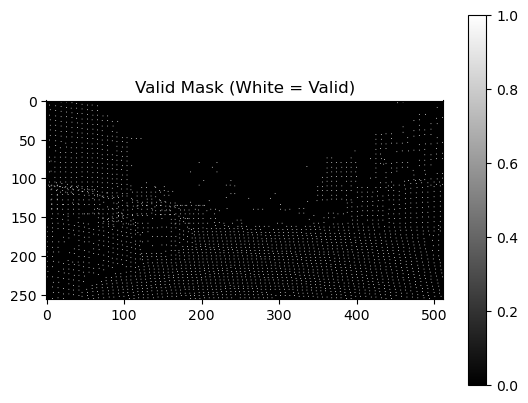

Number of valid elements: 2723
Total elements: 131072
Percentage of valid elements: 2.08%
Number of valid lidar in depth map: 2723


In [8]:
# 2. Find valid comparison pixels (where both have valid depth)
valid_mask = np.isfinite(scene_map).all(axis=2) & np.isfinite(pts3d_im0).all(axis=2)
finite_mask = np.isfinite(depth_map) 
# positive_mask = depth_map > 0
# valid_mask = finite_mask & positive_mask

# 3. Vector depth error
depth_error = np.abs(pts3d_im0[valid_mask] - scene_map[valid_mask])

# 4. Calculate statistics of the error
mean_depth_error = np.median(depth_error, axis=0)
std_depth_error = np.std(depth_error, axis=0)
max_depth_error = np.mean(depth_error, axis=0)
print(mean_depth_error, max_depth_error)

# 5. Calculate L2 norm error
l2_depth_error = np.linalg.norm(pts3d_im0[valid_mask] - scene_map[valid_mask], axis=-1)

# 6. Calculate statistics of the L2 norm error
mean_l2_error = np.mean(l2_depth_error)
median_l2_error = np.median(l2_depth_error)
std_l2_error = np.std(l2_depth_error)

print(f"Mean L2 Depth Error: {mean_l2_error:.4f}")
print(f"Median L2 Depth Error: {median_l2_error:.4f}")
print(f"Std L2 Depth Error: {std_l2_error:.4f}")

# --- Visualize the valid mask ---
plt.imshow(finite_mask, cmap='gray')  # Display the mask as a grayscale image
plt.title("Valid Mask (White = Valid)")
plt.colorbar()
plt.show()

# --- Count the number of valid elements ---
num_valid_elements = np.sum(valid_mask)
print(f"Number of valid elements: {num_valid_elements}")
total_elements = valid_mask.size
print(f"Total elements: {total_elements}")
print(f"Percentage of valid elements: {(num_valid_elements / total_elements) * 100:.2f}%")
print(f"Number of valid lidar in depth map: {len(u)}")



In [9]:
# Compute all localizations for the loaded anchor-query pair

from my_utils.scaling import compute_scaled_points
from my_utils.transformations import se3_to_pose, pose_to_se3
from my_utils.mast3r_utils import solve_pnp

T_base_cam = calib['cam_l']['T_base_cam']

# --- Prepare inlier 3D-2D correspondences ---
if len(inlier_im0) >= 4:
    mast3r_pts = pts3d_im0[inlier_im0[:, 1].astype(int), inlier_im0[:, 0].astype(int)]
    inlier_2d = inlier_im1.astype(np.float32)
else:
    mast3r_pts = np.empty((0, 3))
    lidar_pts = np.empty((0, 3))
    inlier_2d = np.empty((0, 2))

T_anchor_local = pose_to_se3(anchor['pose'])
T_query_local =  pose_to_se3(query['pose'])
pose_query = se3_to_pose(T_query_local)
pose_anchor = se3_to_pose(T_anchor_local)
# --- PnP from MASt3R ---
print(len(inlier_2d))
T_query_anchor_mast3r = solve_pnp(mast3r_pts, inlier_2d, K_new) if len(mast3r_pts) >= 4 else None
if T_query_anchor_mast3r is not None:
    T_m_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_mast3r)
    pose_m = se3_to_pose(T_m_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- PnP from MASt3R (Close Predictions Only) ---
max_distance = 40  # Define maximum distance threshold (in meters)
close_mask = np.linalg.norm(mast3r_pts, axis=1) < max_distance
close_mast3r_pts = mast3r_pts[close_mask]
close_inlier_2d = inlier_2d[close_mask]

from my_utils.mast3r_utils import apply_conf_threshold

pts3d_im0, inlier_im0, inlier_im1 = apply_conf_threshold(output[2],output[0], output[1], output[4], percentile=70)

T_query_anchor_mast3r_close = solve_pnp(pts3d_im0[inlier_im0[:, 1].astype(int), inlier_im0[:, 0].astype(int)], inlier_im1.astype(np.float32), K_new) 
if T_query_anchor_mast3r_close is not None:
    T_m_local_close = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_mast3r_close)
    pose_m_close = se3_to_pose(T_m_local_close)
else:
    pose_m_close = None  # Or some default invalid pose


matched_uv, matched_lidar_uv, matched_indices = overlap(inlier_im0, depth_map, max_pixel_dist=2)
inlier_im0 = inlier_im0[matched_indices]
inlier_im1 = inlier_im1[matched_indices]
lidar_pts = scene_map[matched_lidar_uv[:, 1].astype(int), matched_lidar_uv[:, 0].astype(int)]
mast3r_pts2 = pts3d_im0[inlier_im0[:, 1].astype(int), inlier_im0[:, 0].astype(int)]
inlier_2d = inlier_im1.astype(np.float32)
# --- PnP from LiDAR ---
print(len(matched_indices))
T_query_anchor_lidar = solve_pnp(lidar_pts, inlier_2d, K_new) if len(lidar_pts) >= 4 else None
if T_query_anchor_lidar is not None:
    T_l_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_lidar)
    pose_l = se3_to_pose(T_l_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]


# --- MASt3R scaled v3 (L1 centroid scale) ---
mast3r_pts_scaled_v3, scale_v3 = compute_scaled_points('v3', mast3r_pts2, lidar_pts) if len(mast3r_pts) >= 4 and len(lidar_pts) >= 4 else (np.empty((0, 3)), None)
if scale_v3 is not None:
    print(f"Scale estimated for v3 (L1 centroid scale): {scale_v3}")
T_query_anchor_scaled_v3 = solve_pnp(mast3r_pts_scaled_v3, inlier_2d, K_new) if mast3r_pts_scaled_v3.size > 0 else None
if T_query_anchor_scaled_v3 is not None:
    T_s3_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_scaled_v3)
    pose_s3 = se3_to_pose(T_s3_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- MASt3R scaled v4 (per-axis L1 scale) ---
mast3r_pts_scaled_v4, scale_v4 = compute_scaled_points('v4', mast3r_pts2, lidar_pts) if len(mast3r_pts) >= 4 and len(lidar_pts) >= 4 else (np.empty((0, 3)), None)
if scale_v4 is not None:
    print(f"Scale estimated for v4 (per-axis L1 scale): {scale_v4}")
T_query_anchor_scaled_v4 = solve_pnp(mast3r_pts_scaled_v4, inlier_2d, K_new) if mast3r_pts_scaled_v4.size > 0 else None
if T_query_anchor_scaled_v4 is not None:
    T_s4_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_scaled_v4)
    pose_s4 = se3_to_pose(T_s4_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

# --- MASt3R scaled ICP (Umeyama) ---
mast3r_pts_scaled_icp, scale_icp = compute_scaled_points('icp', mast3r_pts2, lidar_pts) if len(mast3r_pts) >= 4 and len(lidar_pts) >= 4 else (np.empty((0, 3)), None)
if scale_icp is not None:
    print(f"Scale estimated for ICP (Umeyama): {scale_icp}")
T_query_anchor_scaled_icp = solve_pnp(mast3r_pts_scaled_icp, inlier_2d, K_new) if mast3r_pts_scaled_icp.size > 0 else None
if T_query_anchor_scaled_icp is not None:
    T_icp_local = T_anchor_local @ T_base_cam @ np.linalg.inv(T_query_anchor_scaled_icp)
    pose_icp = se3_to_pose(T_icp_local)  # Convert to [tx, ty, tz, qx, qy, qz, qw]

1620


276
Scale estimated for v3 (L1 centroid scale): 1.4809161139484002
Scale estimated for v4 (per-axis L1 scale): [1.1994858 1.1462041 1.5726253]
Scale estimated for ICP (Umeyama): 1.3259931985129816


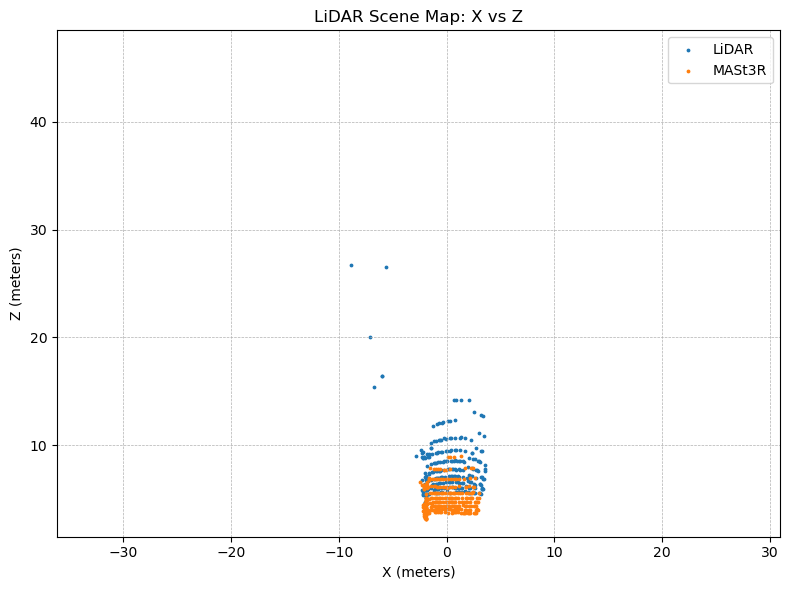

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(scene_map[matched_lidar_uv[:, 1].astype(int), matched_lidar_uv[:, 0].astype(int), 0], scene_map[matched_lidar_uv[:, 1].astype(int), matched_lidar_uv[:, 0].astype(int), 2], s=3, label="LiDAR")
plt.scatter(pts3d_im0[inlier_im0[:, 1].astype(int), inlier_im0[:, 0].astype(int), 0], pts3d_im0[inlier_im0[:, 1].astype(int), inlier_im0[:, 0].astype(int), 2], s=3, label="MASt3R")
plt.xlabel('X (meters)')
plt.ylabel('Z (meters)')
plt.title('LiDAR Scene Map: X vs Z')
plt.legend()
plt.axis('equal')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim([0,50])
plt.tight_layout()
plt.show()

GT Query [75.73971166510925, 1.6732039188017909, 0.9232440652044981, 0.02522600321251293, -0.007665005717123169, 0.00020797469610125835, 0.9996523661732636]
GT Anchor [75.64478967471113, 1.7474139970523752, 0.9285210049547483, 0.03138199373996517, -0.010862001296667936, 0.017347996543801786, 0.9992978707135587]
MASt3R Estimate [69.57646385724274, 2.468303539815385, -0.25718338968171767, -0.479698628444267, 0.501259912486325, -0.4943843894479953, 0.5236523670079454]
MASt3R Estimate Close [74.51010305695138, 1.9431890473180555, 0.5485026791278793, -0.5042940192805128, 0.5143412085869817, -0.46863566095322745, 0.5113915139598233]
LiDAR Estimate [75.832294077474, 1.9830150430057114, 0.276448204724543, -0.4848607088884241, 0.5074330919652016, -0.4900989337956589, 0.516937893027014]


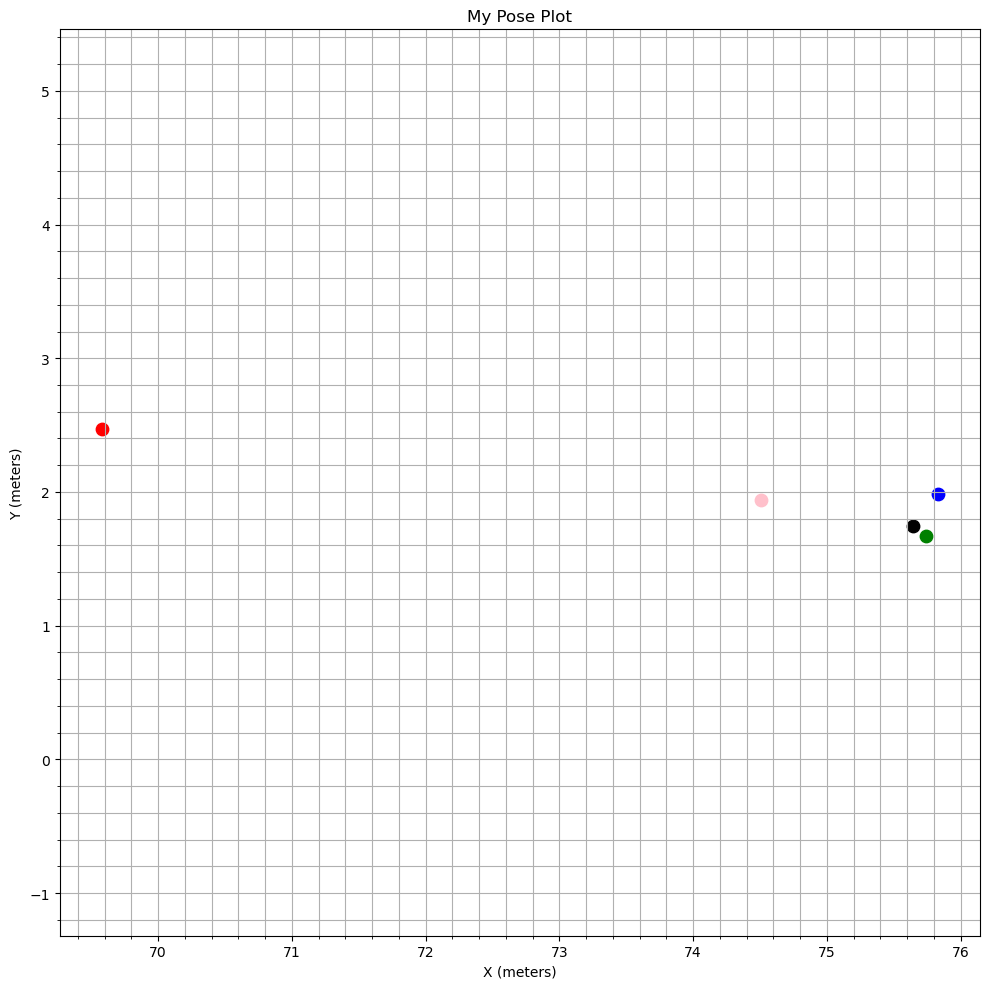

In [11]:
def plot_poses(poses, colors, labels, title="Pose Plot", xlabel="X (meters)", ylabel="Y (meters)"):
    """
    Plots poses on a 2D plane with specified colors and labels.

    Args:
        poses (dict): A dictionary where keys are labels and values are lists of poses (tx, ty, tz, qx, qy, qz, qw).
        colors (dict): A dictionary where keys are labels and values are colors for plotting.
        labels (list): A list of labels for the poses.
        title (str): The title of the plot.
        xlabel (str): The label for the x-axis.
        ylabel (str): The label for the y-axis.
    """
    import matplotlib.pyplot as plt
    from my_utils.transformations import se3_to_pose, pose_to_se3
    import numpy as np

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axis('equal')
    ax.grid(True, which='both')
    ax.minorticks_on()

    for label in labels:
        if label not in poses:
            print(f"Warning: Label '{label}' not found in poses dictionary.")
            continue

        if label not in colors:
            print(f"Warning: Label '{label}' not found in colors dictionary. Using default color 'blue'.")
            color = 'blue'
        else:
            color = colors[label]

        for i, pose in enumerate(poses[label]):
            print(label,pose)
            if pose is not None:
                T = pose_to_se3(pose)
                ax.scatter(T[0, 3], T[1, 3], c=color, marker='o', s=80, label=label if i == 0 else "")


    # Create custom legend without duplicates
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    # ax.legend(by_label.values(), by_label.keys(), loc='best')

    plt.tight_layout()
    plt.show()


from my_utils.transformations import se3_to_pose, pose_to_se3
import numpy as np


poses = {
    "GT Query": [pose_query],
    "GT Anchor": [pose_anchor],
    "MASt3R Estimate": [pose_m],
    "MASt3R Estimate Close": [pose_m_close],
    "LiDAR Estimate": [pose_l]

}
colors = {
    "GT Query": "green",
    "GT Anchor": "black",
    "MASt3R Estimate": "red",
    "MASt3R Estimate Close": "pink",
    "LiDAR Estimate": "blue"
}
labels = ["GT Query", "GT Anchor","MASt3R Estimate","MASt3R Estimate Close", "LiDAR Estimate"]
plot_poses(poses, colors, labels, title="My Pose Plot")

In [12]:
print(pose_query)
print(pose_anchor)

[75.73971166510925, 1.6732039188017909, 0.9232440652044981, 0.02522600321251293, -0.007665005717123169, 0.00020797469610125835, 0.9996523661732636]
[75.64478967471113, 1.7474139970523752, 0.9285210049547483, 0.03138199373996517, -0.010862001296667936, 0.017347996543801786, 0.9992978707135587]
